# LASSO SGP diurnal cycle of cloud fraction

Lin Lin, 2026/4/23, Livermore

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob

Matplotlib is building the font cache; this may take a moment.


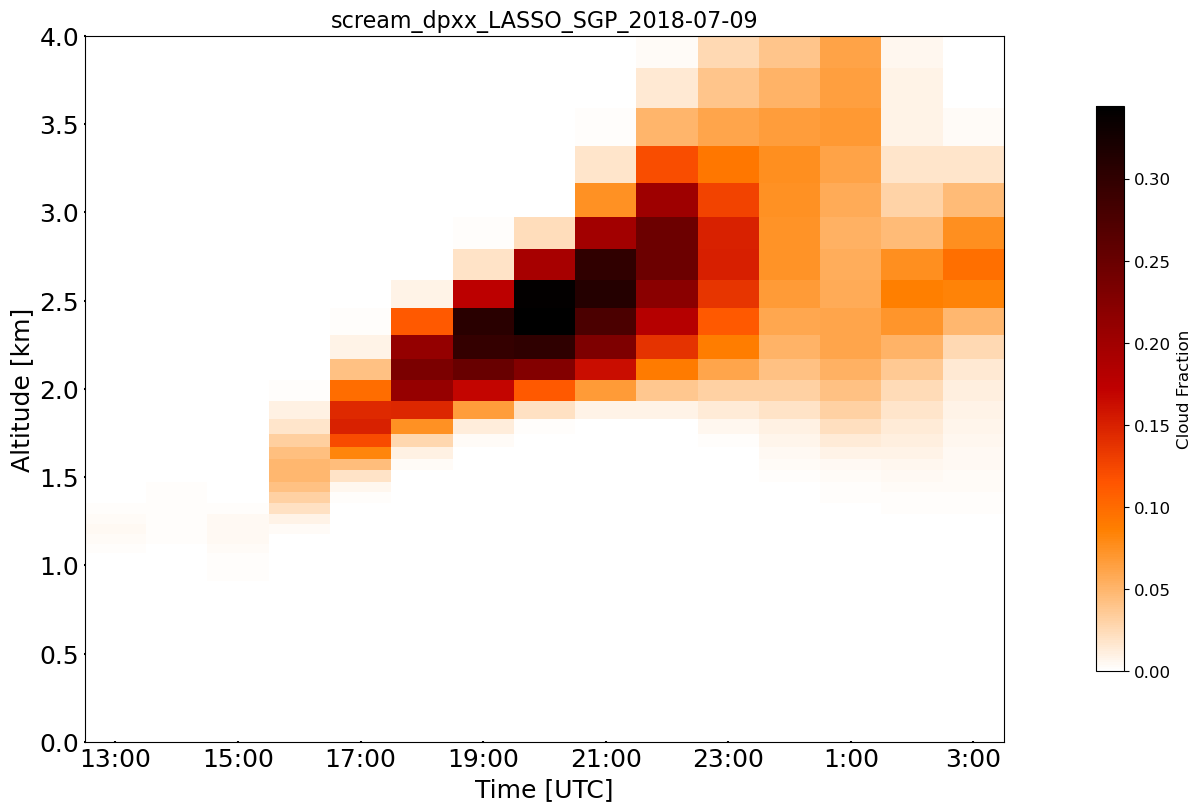

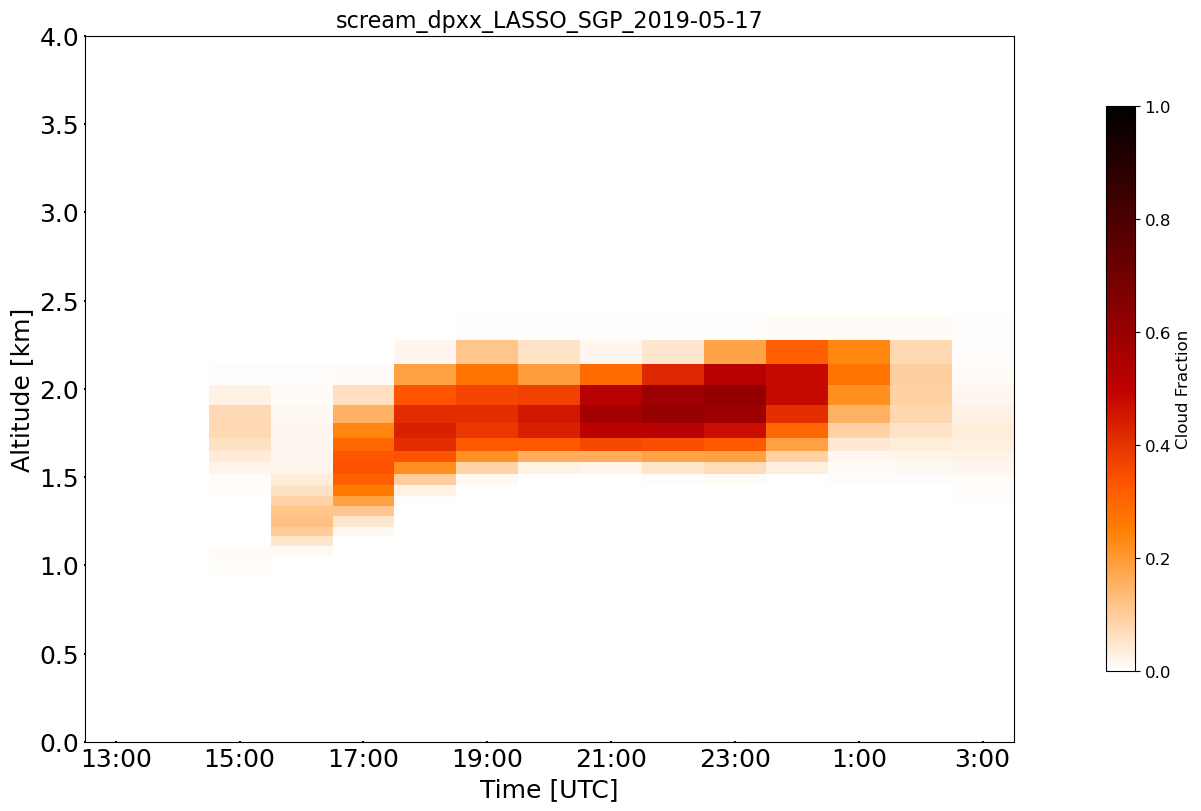

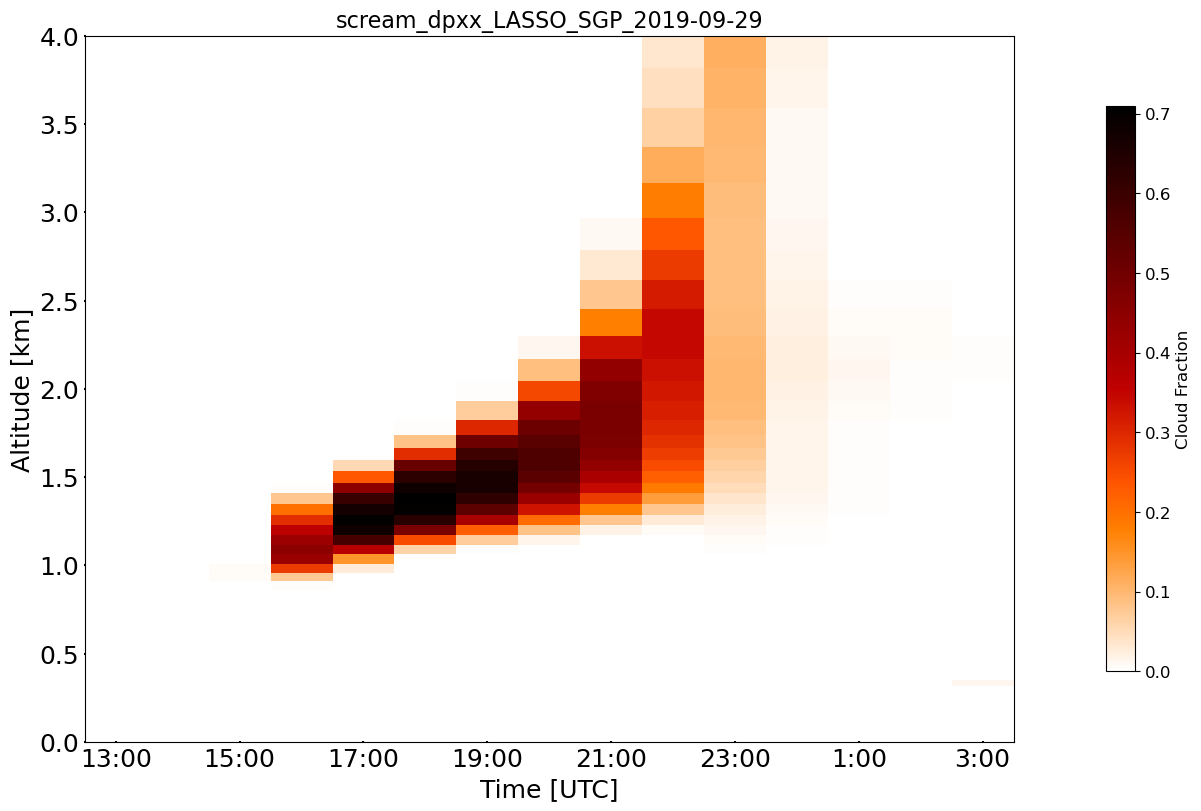

In [24]:
pre_path  = '/pscratch/sd/l/linlin00/DPxx_simulations/LASSO_SGP/'
case_path = ['scream_dpxx_LASSO_SGP_2018-07-09', 
             'scream_dpxx_LASSO_SGP_2019-05-17', 
             'scream_dpxx_LASSO_SGP_2019-09-29',]

cmap1 = plt.get_cmap('gist_heat_r')

for acase in case_path:
    full_path = pre_path + acase + '/run/'
    data_path = glob.glob(full_path + '*fullfield.AVERAGE.nhours_x1*.nc')[0]

    ncfid     = xr.open_dataset(data_path)
    time      = ncfid['time']
    cf        = ncfid['cldfrac_tot_for_analysis'].mean(dim=['ncol'])
    zmid      = ncfid['z_mid'].mean(dim=['time','ncol']).values/1e3

    fig, ax1 = plt.subplots(1, 1, constrained_layout=True, figsize=(12,8))

    ax1.set_ylabel('Altitude [km]',fontsize=18)
    ax1.set_xlabel('Time [UTC]', fontsize=18)
    ax1.set_title(acase,fontsize=16,loc='center')
    ax1.tick_params(axis='both', which='minor',labelsize=18,length=0,direction='inout',width=1.5,color='k')
    ax1.tick_params(axis='both', which='major',labelsize=18,length=1,direction='inout',width=1.5,color='k')
    ax1.set_ylim([0,4])
    # ax1.set_xlim([0,200])
    ax1.set_yscale('linear')
    ax1.set_xticks(time.values[::2], labels=[str(ii.dt.hour.values)+':'+str(ii.dt.minute.values).zfill(2) for ii in time[::2]])
    
    pm = ax1.pcolormesh(time, zmid, cf.transpose(),shading='auto', cmap=cmap1)

    cb1 = plt.colorbar(pm,ax=ax1, shrink=0.8,location='right', pad=0.1,)
    cb1.ax.tick_params(labelsize=12)
    cb1.set_label(label='Cloud Fraction', fontsize=12)

    ncfid.close()
    plt.show()
    plt.close()